# **Predicting Taxi Gratuities in New York City**
**Stage 5 - Machine learning models**

**Situation:** In the current stage we want to **build a machine learning model to predict if a customer will not leave a tip**. NYC TLC want to use the model in an app that will alert taxi drivers to customers who are unlikely to tip, since drivers depend on tips.

# Building a machine learning model

In this stage, we will try using tree-based modeling techniques to predict on a binary target class.  
<br/>   

**The purpose** of this model is to find ways to generate more revenue for taxi cab drivers.  
  
**The goal** of this model is to predict whether or not a customer is a generous tipper.  
<br/>  

*This stage has three parts:*

**Part 1:** Ethical considerations
* Considering the ethical implications of the request

**Part 2:** Feature engineering

* Performing feature selection, extraction, and transformation to prepare our data for modeling

**Part 3:** Modeling

* Building our models, evaluating them, and advising on next steps

# Build a machine learning model

# **PACE stages**


Throughout this notebook, we'll use the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

## PACE: Plan

1. I were asked to develop a random forest machine learning model that predicts wether or not a rider with give a tip.
2. We can't judge people genreuoscity by the amount of tips they are given. Making false negative error may cause drivers time and false positive can cause them potential money
3. The model can be very useful regaredlees of the errors. because it should give as predictions that are more accurate that a random model.
4. I think it would be of a huge benefit.
5. Maybe we should set the goal as : Using factors that affect rider tip amount to predict its tendency to give >=20% tip.

Suppose we were to modify our modeling objective so, instead of predicting people who won't tip at all, we predicted people who are particularly generous&mdash;those who will tip 20% or more.

+ I'm in need of labeled data that contains previuos tip amounts, and trip details and final price and fare amount to make my predictions.
+ My target variable is `tip_amount` or new feature such as `tip_amount_gt20` which is a binary classification category.
+ I recommend using F1 score to balance between precision and recall.

### **Part 1. Imports and data loading**

We start by importing the packages and libraries needed to build and evaluate our random forest and XGBoost classification models.

In [ ]:
# Importing required packages and libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn.metrics as metrics
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pickle

In [ ]:
# Setting pandas options to show all columns, preventing any truncation
pd.set_option('display.max_columns', None)

In [ ]:
# Loading our datasets
df0 = pd.read_csv('2017_Yellow_Taxi_Trip_Data.csv')

# Loading predicted fares and mean distance/duration calculations from our prior analysis
means = pd.read_csv('nyc_preds_means.csv')

Let's inspect the first few rows of our main dataset `df0`.

In [ ]:
# Inspecting the top 10 rows of df0
df0.head(10)

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80
5,23345809,2,03/25/2017 8:34:11 PM,03/25/2017 8:42:11 PM,6,2.30,1,N,161,236,1,9.0,0.5,0.5,2.06,0.0,0.3,12.36
6,37660487,2,05/03/2017 7:04:09 PM,05/03/2017 8:03:47 PM,1,12.83,1,N,79,241,1,47.5,1.0,0.5,9.86,0.0,0.3,59.16
7,69059411,2,08/15/2017 5:41:06 PM,08/15/2017 6:03:05 PM,1,2.98,1,N,237,114,1,16.0,1.0,0.5,1.78,0.0,0.3,19.58
8,8433159,2,02/04/2017 4:17:07 PM,02/04/2017 4:29:14 PM,1,1.20,1,N,234,249,2,9.0,0.0,0.5,0.00,0.0,0.3,9.80
9,95294817,1,11/10/2017 3:20:29 PM,11/10/2017 3:40:55 PM,1,1.60,1,N,239,237,1,13.0,0.0,0.5,2.75,0.0,0.3,16.55


Now, let's examine the first few rows of `nyc_preds_means`.

In [ ]:
# Checking the initial rows of the means dataframe
means.head()

,mean_duration,mean_distance,predicted_fare
0,22.847222,3.521667,16.434245
1,24.470370,3.108889,16.052218
2,7.250000,0.881429,7.053706
3,30.250000,3.700000,18.731650
4,14.616667,4.435000,15.845642


#### Join the two dataframes

We'll join the two dataframes together side-by-side.

In [ ]:
# Merging the datasets along the column axis
df = pd.concat([df0, means], axis=1)

## PACE: **Analyze**

### **Part 2. Feature engineering**

We have already prepped a significant portion of this dataset and performed exploratory data analysis (EDA) during the earlier phases of our work.

Let's check the structure of our new combined dataframe.

In [ ]:
# Calling info() to inspect the combined dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

We know from our EDA that customers who pay cash generally have a tip amount of $0. To meet our modeling objective, we'll filter our data to select only the customers who pay with a credit card.

We will copy `df` to `df1` and filter it using a Boolean mask so it only contains transactions where the payment type indicates credit card usage.

In [ ]:
# Filtering our data to isolate only credit card transactions
df1 = df[df['payment_type']==1]

##### **Target**

Notice that we don't have a column indicating the tip percentage, which we need to establish our target variable. We'll engineer this column.

We'll add a `tip_percent` column by performing the following computation:  
<br/>  

$$tip\ percent = \frac{tip\ amount}{total\ amount - tip\ amount}$$

Rounding this result to three decimal places is a crucial step. It determines how many customers are categorized as generous. Without rounding, roughly 1,800 passengers who tipped exactly 20% or more would be misclassified due to floating-point anomalies.

This happens because of how computer processors execute calculations. Floating-point math represents extremely large and extremely small values in binary with limited bit precision (usually 32 or 64 bits).

As a result, calculations that should yield simple, clean numbers occasionally produce long decimals.

In [ ]:
# Calculating the tip percentage and rounding it to 3 decimal places
df1['tip_percent'] = round(df1['tip_amount'] / (df1['total_amount'] - df1['tip_amount']), 3)

Now we'll construct our target column, `generous`. This binary target column will indicate whether a customer tipped 20% or more (0 for no, 1 for yes).

We will accomplish this by:
1. Initializing our `generous` column as a copy of `tip_percent`.
2. Converting the conditions to Boolean flags (True/False).
3. Converting those Boolean values into binary integers (1/0).

In [ ]:
# Engineering our binary target variable 'generous'
df1['generous'] = np.where(df1['tip_percent'] >= 0.2, 1, 0)

#### Creating day column

Next, we'll process the pickup and dropoff timestamp columns.

We'll convert both `tpep_pickup_datetime` and `tpep_dropoff_datetime` into pandas datetime objects.

In [ ]:
# Converting datetime string columns to datetime objects
df1['tpep_pickup_datetime'] = pd.to_datetime(df1['tpep_pickup_datetime'])
df1['tpep_dropoff_datetime'] = pd.to_datetime(df1['tpep_dropoff_datetime'])

We'll extract the day of the week for each pickup, place it into a new `day` column, and format the day names in lowercase.

In [ ]:
# Extracting and lowercase-formatting the pickup day names
df1['day'] = df1['tpep_pickup_datetime'].dt.day_name().str.lower()

#### Creating time of day columns

Next, we'll build four binary indicators representing different shifts of the day. Each column will indicate (0=no, 1=yes) if a trip started within these specific intervals:

`am_rush` = [06:00&ndash;10:00)  
`daytime` = [10:00&ndash;16:00)  
`pm_rush` = [16:00&ndash;20:00)  
`nighttime` = [20:00&ndash;06:00)  

To prepare, we'll first create these columns and populate them with the hour of day from the pickup timestamp.

In [ ]:
# Extracting pickup hour to populate our shift bins
df1['am_rush'] = df1['tpep_pickup_datetime'].dt.hour
df1['daytime'] = df1['tpep_pickup_datetime'].dt.hour
df1['pm_rush'] = df1['tpep_pickup_datetime'].dt.hour
df1['night_time'] = df1['tpep_pickup_datetime'].dt.hour

We will map these hour variables to binary categories. Let's start with `am_rush`, converting hours from [06:00 to 10:00) to 1, and all other hours to 0.

In [ ]:
# Defining the am_rush criteria using a list comprehension
am_rush = [1 if i in [6,7,8,9] else 0 for i in df1['am_rush']]

Now, we will apply the conversion to our `am_rush` column and examine the first few rows to verify the changes.

In [ ]:
# Assigning our mapped binary indicators back to the am_rush column
df1['am_rush'] = am_rush

We'll apply the same process to convert the remaining shift columns.

In [ ]:
# Mapping hours to create the binary daytime indicator
daytime = [1 if i in [10,11,12,13,14,15] else 0 for i in df1['daytime']]

In [ ]:
# Saving our daytime mapping back to the dataframe
df1['daytime'] = daytime

In [ ]:
# Mapping hours to create the binary pm_rush indicator
pm_rush = [1 if i in [16,17,18,19] else 0 for i in df1['pm_rush']]

In [ ]:
# Saving our pm_rush mapping back to the dataframe
df1['pm_rush'] = pm_rush

In [ ]:
# Mapping hours to create the binary nighttime indicator
nighttime = [1 if i in [20,21,22,23,24,0,1,2,3,4,5] else 0 for i in df1['night_time']]

In [ ]:
# Saving our nighttime mapping back to the dataframe
df1['night_time'] = nighttime

#### Creating `month` column

Next, we'll extract the abbreviated month name from each pickup, saving it in lowercase format inside a new `month` column.

In [ ]:
# Creating the 'month' column from pickup datetimes
df1['month'] = df1['tpep_pickup_datetime'].dt.month_name().str.lower()

Let's review the first few rows of our modified dataframe.

In [ ]:
# Taking a quick look at our updated dataframe
df1.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,mean_duration,mean_distance,predicted_fare,tip_percent,generous,day,am_rush,daytime,pm_rush,night_time,month
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56,22.847222,3.521667,16.434245,0.200,1,saturday,1,0,0,0,march
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80,24.470370,3.108889,16.052218,0.238,1,tuesday,0,1,0,0,april
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75,7.250000,0.881429,7.053706,0.199,0,friday,1,0,0,0,december
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69,30.250000,3.700000,18.731650,0.300,1,sunday,0,1,0,0,may
5,23345809,2,2017-03-25 20:34:11,2017-03-25 20:42:11,6,2.30,1,N,161,236,1,9.0,0.5,0.5,2.06,0.0,0.3,12.36,11.855376,2.052258,10.441351,0.200,1,saturday,0,0,0,1,march


#### Drop columns

We'll drop redundant features, tracking IDs, and target-leaking variables that won't be available at runtime. This includes columns like payment type, ride distance, tip metrics, total charges, tolls, etc. We will make sure to keep our target `generous` since we need to isolate it as our labels column.

In [ ]:
# Dropping columns that leak target info or are redundant
df = df1.drop(columns=['payment_type','trip_distance','tip_amount','tip_percent','total_amount','tolls_amount','Unnamed: 0', 'fare_amount','improvement_surcharge','mta_tax','extra'])

#### Variable encoding

Several of our columns are categorical and need to be dummy encoded. Some of these features are currently stored as numbers but are actually labels, such as `RatecodeID` and the location zone IDs. To make sure pandas encodes them properly, we will cast them to strings first.

1. Let's define `cols_to_str` containing our numerical categoricals.
2. We'll iterate through this list to perform the string casting.

In [ ]:
# Specifying categorical columns stored as numerical types
cols_to_str = ['RatecodeID', 'PULocationID', 'DOLocationID']

# Converting each of these columns to string types
for col in cols_to_str:
    df[col] = df[col].astype(str)

Now, we will convert all our categorical columns to dummy variables.

1. We'll use `get_dummies()` and save the output in a new dataframe `df2`.

In [ ]:
# Creating dummy variables from categorical columns
df2 = pd.get_dummies(df, dtype=int)
df2.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                   int64
mean_duration                   float64
                              ...      
month_march                       int64
month_may                         int64
month_november                    int64
month_october                     int64
month_september                   int64
Length: 356, dtype: object

##### Evaluation metric

Before launching our models, we need to choose our primary optimization metric.

1. Let's look at the class balance of our target column.

In [ ]:
# Checking the proportion of each class in our target
df['generous'].value_counts(normalize=True)

generous
1    0.526368
0    0.473632
Name: proportion, dtype: float64

Roughly 52.6% of the rides resulted in a "generous" tip (>= 20%). The classes are almost perfectly balanced.

To pick the best metric, let's consider the cost of each error type:
* False Positives (predicting a >= 20% tip, but receiving less): This frustrates our drivers because they expect a high tip and don't get one.
* False Negatives (predicting a < 20% tip, but the customer would have tipped more): This hurts riders since drivers might pass them up for someone predicted to tip better.

**Both errors carry significant weight. We want to support drivers without alienating passengers. Therefore, we should weigh precision and recall equally.

> F1 score for sure!

## PACE: **Construct**

### **Part 3. Modeling**

##### **Split the data**

Now, we'll split our data into features and targets, and then into train/test subsets.

1. Let's isolate our target `y` using the `generous` column.
2. Let's isolate our features `X` by dropping the target and timestamp columns.
3. We'll partition the data, setting aside 20% for testing, making sure to stratify our split and set our random state.

In [ ]:
# Splitting our features and targets
y = df2['generous']
x = df2.drop(columns=['generous', 'tpep_dropoff_datetime', 'tpep_pickup_datetime'], axis=1)

# Splitting into training and testing partitions
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)

##### **Random forest**

We'll start by setting up a `GridSearchCV` to optimize a random forest classifier.

1. Let's initialize our random forest estimator `rf` with a random seed.
2. We'll define a dictionary `cv_params` containing the hyperparameter options we wish to evaluate.
3. We'll declare a set of metrics (`scoring`) for our GridSearch to capture.
4. We'll instantiate our `GridSearchCV` object as `rf1`.

In [ ]:
# Initializing our random forest classifier
rf = RandomForestClassifier(random_state=42)

# Defining our hyperparameter search space
cv_params = {'max_depth':[3,4,5]
             ,'max_features':['sqrt'],
             'max_samples':[0.5,0.7,0.9],
             'min_samples_leaf':[2,3],
             'min_samples_split':[10,15],
             'n_estimators':[10,15,20]}

# Declaring the evaluation metrics to capture
scoring = ['accuracy','precision','recall','f1']

# Setting up our GridSearchCV configuration
rf1 = GridSearchCV(rf, cv_params, cv=5, scoring=scoring, refit='f1', error_score='raise')
x_train.head()

,VendorID,passenger_count,mean_duration,mean_distance,predicted_fare,am_rush,daytime,pm_rush,night_time,RatecodeID_1,RatecodeID_2,RatecodeID_3,RatecodeID_4,RatecodeID_5,RatecodeID_99,store_and_fwd_flag_N,store_and_fwd_flag_Y,PULocationID_1,PULocationID_10,PULocationID_100,PULocationID_106,PULocationID_107,PULocationID_112,PULocationID_113,PULocationID_114,PULocationID_116,PULocationID_12,PULocationID_123,PULocationID_125,PULocationID_127,PULocationID_128,PULocationID_129,PULocationID_13,PULocationID_130,PULocationID_131,PULocationID_132,PULocationID_133,PULocationID_134,PULocationID_135,PULocationID_137,PULocationID_138,PULocationID_140,PULocationID_141,PULocationID_142,PULocationID_143,PULocationID_144,PULocationID_145,PULocationID_146,PULocationID_148,PULocationID_151,PULocationID_152,PULocationID_153,PULocationID_158,PULocationID_161,PULocationID_162,PULocationID_163,PULocationID_164,PULocationID_166,PULocationID_17,PULocationID_170,PULocationID_173,PULocationID_179,PULocationID_181,PULocationID_186,PULocationID_188,PULocationID_189,PULocationID_190,PULocationID_193,PULocationID_196,PULocationID_208,PULocationID_209,PULocationID_211,PULocationID_213,PULocationID_216,PULocationID_218,PULocationID_223,PULocationID_224,PULocationID_225,PULocationID_226,PULocationID_229,PULocationID_230,PULocationID_231,PULocationID_232,PULocationID_233,PULocationID_234,PULocationID_236,PULocationID_237,PULocationID_238,PULocationID_239,PULocationID_24,PULocationID_243,PULocationID_244,PULocationID_246,PULocationID_247,PULocationID_249,PULocationID_25,PULocationID_255,PULocationID_256,PULocationID_258,PULocationID_260,PULocationID_261,PULocationID_262,PULocationID_263,PULocationID_264,PULocationID_265,PULocationID_28,PULocationID_33,PULocationID_35,PULocationID_36,PULocationID_37,PULocationID_4,PULocationID_40,PULocationID_41,PULocationID_42,PULocationID_43,PULocationID_45,PULocationID_48,PULocationID_49,PULocationID_50,PULocationID_52,PULocationID_57,PULocationID_61,PULocationID_62,PULocationID_65,PULocationID_66,PULocationID_68,PULocationID_7,PULocationID_70,PULocationID_74,PULocationID_75,PULocationID_79,PULocationID_80,PULocationID_82,PULocationID_87,PULocationID_88,PULocationID_90,PULocationID_91,PULocationID_92,PULocationID_93,PULocationID_95,PULocationID_97,DOLocationID_1,DOLocationID_10,DOLocationID_100,DOLocationID_102,DOLocationID_106,DOLocationID_107,DOLocationID_11,DOLocationID_112,DOLocationID_113,DOLocationID_114,DOLocationID_116,DOLocationID_117,DOLocationID_118,DOLocationID_119,DOLocationID_12,DOLocationID_120,DOLocationID_121,DOLocationID_123,DOLocationID_124,DOLocationID_125,DOLocationID_126,DOLocationID_127,DOLocationID_129,DOLocationID_13,DOLocationID_130,DOLocationID_131,DOLocationID_132,DOLocationID_133,DOLocationID_134,DOLocationID_135,DOLocationID_136,DOLocationID_137,DOLocationID_138,DOLocationID_14,DOLocationID_140,DOLocationID_141,DOLocationID_142,DOLocationID_143,DOLocationID_144,DOLocationID_145,DOLocationID_146,DOLocationID_147,DOLocationID_148,DOLocationID_15,DOLocationID_151,DOLocationID_152,DOLocationID_153,DOLocationID_157,DOLocationID_158,DOLocationID_159,DOLocationID_16,DOLocationID_160,DOLocationID_161,DOLocationID_162,DOLocationID_163,DOLocationID_164,DOLocationID_166,DOLocationID_168,DOLocationID_169,DOLocationID_17,DOLocationID_170,DOLocationID_173,DOLocationID_174,DOLocationID_175,DOLocationID_177,DOLocationID_178,DOLocationID_179,DOLocationID_180,DOLocationID_181,DOLocationID_182,DOLocationID_183,DOLocationID_186,DOLocationID_188,DOLocationID_189,DOLocationID_19,DOLocationID_192,DOLocationID_193,DOLocationID_194,DOLocationID_195,DOLocationID_196,DOLocationID_197,DOLocationID_198,DOLocationID_200,DOLocationID_202,DOLocationID_208,DOLocationID_209,DOLocationID_21,DOLocationID_210,DOLocationID_211,DOLocationID_212,DOLocationID_213,DOLocationID_216,DOLocationID_217,DOLocationID_218,DOLocationID_22,DOLocationID_220,DOLocationID_223,DOLocationID_224,DOLocationID_225,DOLocationID_226,DOLocationID_228,DOLocatio

Now we'll fit this model onto our training partitions. Depending on our parameter choices and cross-validation setup, this search could take a while. Our current setup is light and should complete quickly.

In [ ]:
# Timing and executing our random forest grid search
%time
#rf1.fit(x_train, y_train)

CPU times: user 5 µs, sys: 1 µs, total: 6 µs
Wall time: 10 µs


GridSearchCV(cv=5, error_score='raise',
             estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [3, 4, 5], 'max_features': ['sqrt'],
                         'max_samples': [0.5, 0.7, 0.9],
                         'min_samples_leaf': [2, 3],
                         'min_samples_split': [10, 15],
                         'n_estimators': [10, 15, 20]},
             refit='f1', scoring=['accuracy', 'precision', 'recall', 'f1'])

If needed, we can save our progress using `pickle` so we can reload the models later without needing to repeat the search.

In [ ]:
# Defining our save directory and exporting our fitted search object
path = '/home/jovyan/work/'
write_pickle(path, rf1, 'Random Forest')

In [ ]:
# Defining a utility function to serialize our models
def write_pickle(path, model_object, save_name:str):
    '''
    Saves our model object to the specified path.
    '''
    with open(path + save_name + '.pickle', 'wb') as to_write:
        pickle.dump(model_object, to_write)

In [ ]:
# Defining a utility function to reload our models
def read_pickle(path, saved_model_name:str):
    '''
    Loads our saved model object from the specified path.
    '''
    with open(path + saved_model_name + '.pickle', 'rb') as to_read:
        model = pickle.load(to_read)
        return model

Let's check the top score achieved across the validation folds.

In [ ]:
# Extracting our best validation score and estimator details
rf1.best_score_
rf1.best_estimator_

RandomForestClassifier(max_depth=4, max_samples=0.9, min_samples_leaf=3,
                       min_samples_split=15, n_estimators=15, random_state=42)

Now, let's examine the exact combination of hyperparameters that yielded this top result.

In [ ]:
# Retrieving our best hyperparameter values
rf1.best_params_

{'max_depth': 4,
 'max_features': 'sqrt',
 'max_samples': 0.9,
 'min_samples_leaf': 3,
 'min_samples_split': 15,
 'n_estimators': 15}

We'll build a helper function `make_results()` to gather and output our metrics.

In [ ]:
# Defining our metrics report generator
def make_results(model_name:str, model_object, metric:str):
    '''
    Formats our cross-validation performance into a clean table.
    '''
    metric_dict = {'precision': 'mean_test_precision',
                 'recall': 'mean_test_recall',
                 'f1': 'mean_test_f1',
                 'accuracy': 'mean_test_accuracy',
                 }

    cv_results = pd.DataFrame(model_object.cv_results_)
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    table = pd.DataFrame({'model': [model_name],
                        'precision': [precision],
                        'recall': [recall],
                        'F1': [f1],
                        'accuracy': [accuracy],
                        },
                       )
    return table

Let's call `make_results()` to look at our metrics table.

In [ ]:
# Generating and showing our performance summary table
make_results('Random Forest', rf1, metric='f1')

,model,precision,recall,F1,accuracy
0,Random Forest,0.694375,0.809429,0.747442,0.712086


Our model shows very solid, acceptable performance across the board. Generally, scores above 0.65 meet our standards, though this depends heavily on driver/customer impact.

We'll now use our best estimator to predict outcomes on our holdout test data, saving the results in `rf_preds`.

For our evaluation, we will test multiple models on our test set. Let's think about the advantages and disadvantages of this workflow choice.

> The benifit is that we know what our model would perform on real data. the draw back is that the choosen model might overfit the test data.

In [ ]:
# Generating predictions on our test partition
rf1_preds = rf1.best_estimator_.predict(x_test)

We will use the helper function `get_test_scores()` below to print our final performance scores on our holdout data.

In [ ]:
# Creating a function to generate test performance reports
def get_test_scores(model_name:str, preds, y_test_data):
    '''
    Calculates final metrics on our holdout testing data.
    '''
    accuracy = metrics.accuracy_score(y_test_data, preds)
    precision = metrics.precision_score(y_test_data, preds)
    recall = metrics.recall_score(y_test_data, preds)
    f1 = metrics.f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                        'precision': [precision],
                        'recall': [recall],
                        'F1': [f1],
                        'accuracy': [accuracy]
                        })
    return table

1. We'll run our `get_test_scores()` helper to compute test set metrics and save the outputs to `rf_test_scores`.
2. We'll inspect the results.

###### RF test results

In [ ]:
# Running our testing score evaluation
rf_test_scores = get_test_scores('Random Forest', rf1_preds, y_test)

> The models performs almost the same on test data with higher recall and f1 scores and lower precision and accuracy scores.

##### **XGBoost**

Now, we'll try to improve our metrics by training an XGBoost model.

1. Let's initialize our XGBoost classifier `xgb` with a logistic loss objective and set our seed.
2. We'll set up a search dictionary `cv_params` with hyperparameters to tune.
3. We'll utilize our predefined metrics set to capture during tuning.
4. We'll set up our `GridSearchCV` object as `xgb1`.

In [ ]:
# Initializing our XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=42)

# Building our hyperparameter combinations to evaluate
cv_params = {'max_depth':[3,4,5,6],
            'min_child_weight':[5,10],
            'learning_rate':[0.01,0.1,0.3],
            'n_estimators':[75,100,150,200]}

# Setting up our XGBoost GridSearchCV run
xgb1 = GridSearchCV(xgb, cv_params, cv=5, refit='f1', scoring=scoring)

Now, let's fit this XGBoost model onto our training partitions.

In [ ]:
%%time
# Training our XGBoost grid search
xgb1.fit(x_train, y_train)

CPU times: user 10min 49s, sys: 2.45 s, total: 10min 52s
Wall time: 6min 18s


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.3],
                         'max_depth': [3, 4, 5, 6], 'min_child_weight': [5, 10],
                         'n_estimators': [75, 100, 150, 200]},
             refit='f1', scoring=['accuracy', 'precision', 'recall', 'f1'])

Let's retrieve the best validation score achieved by this XGBoost run.

In [ ]:
# Extracting our best XGBoost score
xgb1.best_score_

0.7491168956820593

And let's view the corresponding hyperparameter combination.

In [ ]:
# Reviewing our best parameter settings
xgb1.best_params_

{'learning_rate': 0.01,
 'max_depth': 3,
 'min_child_weight': 5,
 'n_estimators': 75}

##### XGB CV Results

We will use our helper function to display our full cross-validation metrics.

In [ ]:
# Formatting our XGBoost validation results
make_results('XGBoost', xgb1, 'f1')

,model,precision,recall,F1,accuracy
0,XGBoost,0.692139,0.816428,0.749117,0.712167


We will generate predictions on our holdout set using our best XGBoost configuration, storing them in `xgb_preds`.

In [ ]:
# Generating holdout test predictions from our best XGBoost estimator
xgb_preds = xgb1.best_estimator_.predict(x_test)

###### XGB test results

1. Let's calculate our XGBoost test metrics using `get_test_scores()` and save them as `xgb_test_scores`.
2. We'll print the outputs to compare both of our models.

In [ ]:
# Saving our XGBoost run to disk and combining model scores for side-by-side comparison
write_pickle(path, xgb1, 'XGBoost')
get_test_scores('XGBoost', xgb_preds, y_test).merge(rf_test_scores, how='outer')

,model,precision,recall,F1,accuracy
0,Random Forest,0.681631,0.822029,0.745275,0.704225
1,XGBoost,0.686059,0.814561,0.744808,0.706191


> Random Forest preforms better in recall and f1 score, while XGBoost is better in accuracy and precision.

Now, let's plot a confusion matrix of our test predictions.

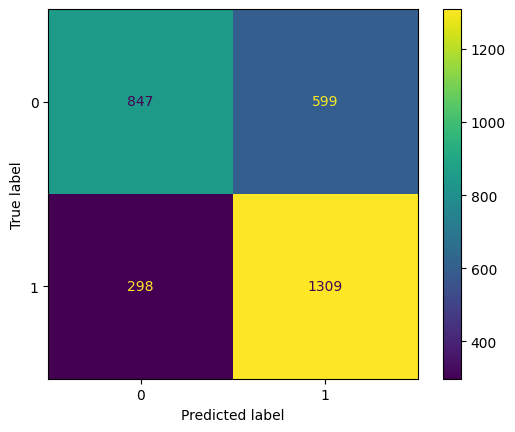

In [ ]:
# Calculating the confusion matrix array values
cm = metrics.confusion_matrix(y_test, xgb_preds)
# Plotting our confusion matrix visualization
metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb1.best_estimator_.classes_).plot()

> False positive errors is more common in XGBoost model.

##### Feature importance

We will extract the `feature_importances_` attribute from our model to inspect the relative impact of our features, and then plot the top contributors.

<Axes: >

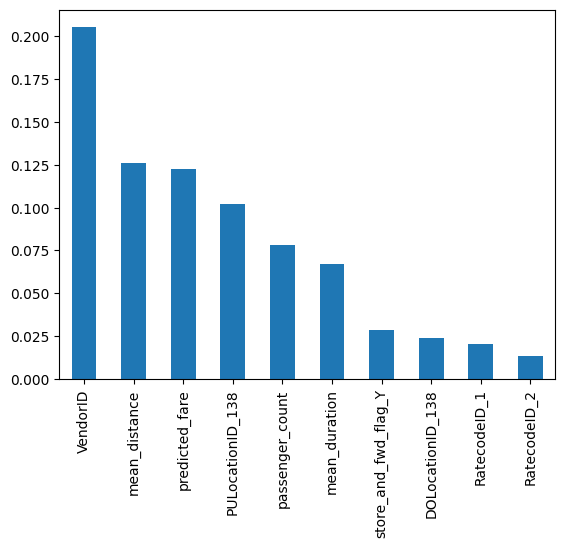

In [ ]:
# Sorting and plotting the top 10 features for our Random Forest model
pd.Series(rf1.best_estimator_.feature_importances_, index=x.columns).sort_values(ascending=False)[:10].plot.bar()

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

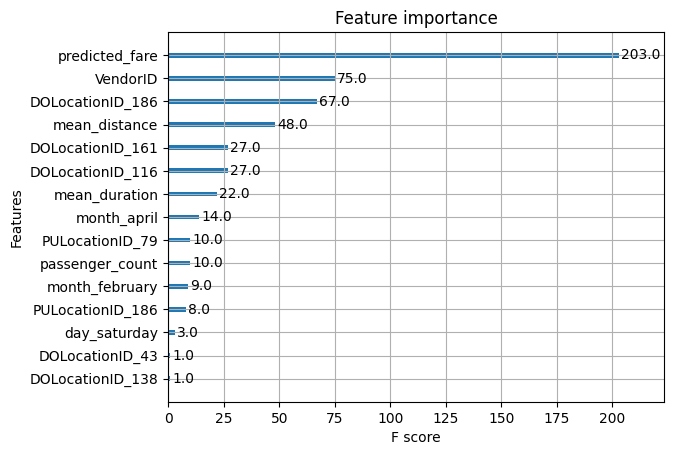

In [ ]:
# Plotting XGBoost feature importance metrics
from xgboost import plot_importance
plot_importance(xgb1.best_estimator_)

## PACE: **Execute**

### **Part 4. Conclusion**

In this step, we use the results of our models above to formulate a conclusion.

**Key takeaways:**
1. I would recommend using this model for predicting if users will give 20% tip because it shows high true positive and true negatives values. Eventhough it makes high false positives values this won't affect the riders and the drivers should be aware that this is gust a guess.
2. Our model was spllitting each observation into yes or no deppending on specific features set by the data team. using this splitting it classified data into one of to categories, 0 or 1.
3. Maybe we can try `distance_per_dollar` where riders that ride trips with high distance and less fare amount might tend to give more tips.
4. Maybe we can add a binary feature `music/radio` and `conditioner` that detects whether the driver provide intertaninment for riders